# MILESTONE 3: Route, Cancellation, And Seasonal Analysis

Import Libraries

In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)



Load Dataset

In [2]:
df = pd.read_csv("../data/processed/week2_processed.csv")

print("Shape:", df.shape)
print("Columns:\n", df.columns.tolist())


Shape: (98619, 32)
Columns:
 ['Passenger_ID', 'First_Name', 'Last_Name', 'Passenger_Full_Name', 'Gender', 'Age', 'Age_Group', 'Nationality', 'Airport_Name', 'Airport_Country_Code', 'Country_Name', 'Airport_Continent', 'Continents', 'Airport_Location', 'Airport_Congestion', 'Departure_Date', 'Departure_Year', 'Departure_Month', 'Departure_Day', 'Departure_DayOfWeek', 'Month_Name', 'Monthly_Traffic', 'Weekly_Traffic', 'Arrival_Airport', 'Pilot_Name', 'Pilot_Workload', 'Flight_Status', 'Is_Flight_Delayed', 'Delay_Cause', 'Delay_Severity', 'Operational_Risk', 'Flight_Type']


In [3]:
df.head()

,Passenger_ID,First_Name,Last_Name,Passenger_Full_Name,Gender,Age,Age_Group,Nationality,Airport_Name,Airport_Country_Code,...,Weekly_Traffic,Arrival_Airport,Pilot_Name,Pilot_Workload,Flight_Status,Is_Flight_Delayed,Delay_Cause,Delay_Severity,Operational_Risk,Flight_Type
0,ABVWIg,Edithe,Leggis,Edithe Leggis,Female,62,Senior Citizen,Japan,Coldfoot Airport,US,...,8386.0,CXF,Fransisco Hazeldine,1,On Time,0,No Delay,No Impact,Low Risk,International
1,jkXXAX,Elwood,Catt,Elwood Catt,Male,62,Senior Citizen,Nicaragua,Kugluktuk Airport,CA,...,8758.0,YCO,Marla Parsonage,1,On Time,0,No Delay,No Impact,Low Risk,International
2,CdUz2g,Darby,Felgate,Darby Felgate,Male,67,Senior Citizen,Russia,Grenoble-Isère Airport,FR,...,8386.0,GNB,Rhonda Amber,1,On Time,0,No Delay,No Impact,Low Risk,International
3,BRS38V,Dominica,Pyle,Dominica Pyle,Female,71,Senior Citizen,China,Ottawa / Gatineau Airport,CA,...,8462.0,YND,Kacie Commucci,1,Delayed,1,Operational / Technical,Operational Impact,Medium Risk,International
4,9kvTLo,Bay,Pencost,Bay Pencost,Male,21,Youth,China,Gillespie Field,US,...,8462.0,SEE,Ebonee Tree,1,On Time,0,No Delay,No Impact,Low Risk,International


Define Columns

In [4]:
origin_col = 'Airport_Name'
dest_col = 'Arrival_Airport'
delay_flag = 'Is_Flight_Delayed'
delay_cause = 'Delay_Cause'
month_col = 'Departure_Month'

Labels Function

In [5]:
def add_labels(ax, total=None):
    for p in ax.patches:
        value = p.get_height()
        if total:
            label = f"{int(value)} ({value/total*100:.1f}%)"
        else:
            label = f"{int(value)}"
        ax.annotate(
            label,
            (p.get_x() + p.get_width()/2, value),
            ha="center",
            va="bottom",
            fontsize=9
        )

Create Route

In [6]:
df['ROUTE'] = df[origin_col].astype(str) + "-" + df[dest_col].astype(str)

Top Routes

Max route frequency: 36


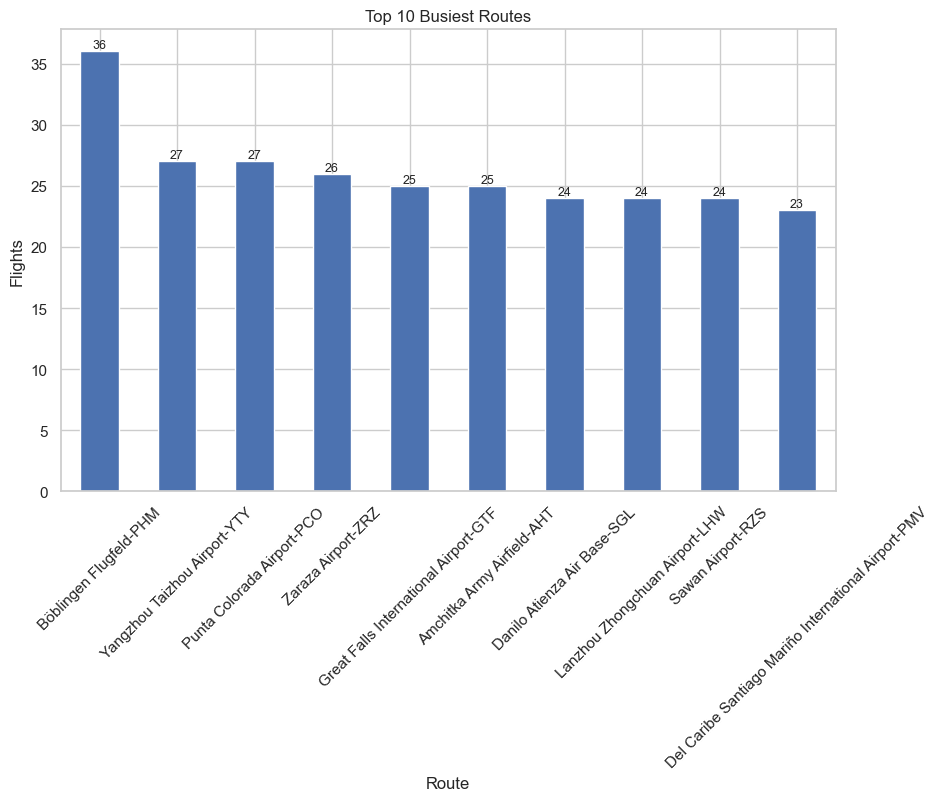

In [7]:

route_counts = df['ROUTE'].value_counts()

print("Max route frequency:", route_counts.max())

# Adaptive threshold (IMPORTANT FIX)
threshold = max(5, int(route_counts.max() * 0.1))

valid_routes = route_counts[route_counts >= threshold].index

df_filtered = df[df['ROUTE'].isin(valid_routes)]

# Fallback if still empty
if df_filtered.empty:
    print("Fallback: using full dataset")
    df_filtered = df.copy()

top_routes = df_filtered['ROUTE'].value_counts().head(10)

plt.figure()
ax = top_routes.plot(kind='bar')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Flights")
plt.xticks(rotation=45)
add_labels(ax)
plt.show()

Route Delay Rate

Airport Aanalysis

In [8]:
airport_stats = df.groupby(origin_col).agg({delay_flag:'mean', origin_col:'count'}).rename(columns={origin_col:'FLIGHT_COUNT'})

threshold_air = max(5, int(airport_stats['FLIGHT_COUNT'].max()*0.1))
airport_filtered = airport_stats[airport_stats['FLIGHT_COUNT'] >= threshold_air]

Busiest Airports

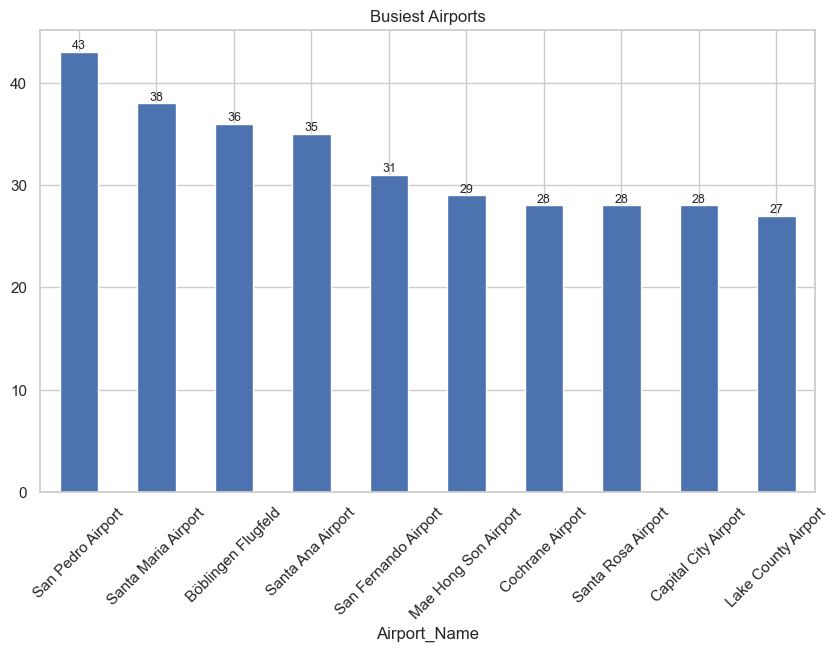

In [9]:
busiest = airport_filtered['FLIGHT_COUNT'].sort_values(ascending=False).head(10)

plt.figure()
ax = busiest.plot(kind='bar')
plt.title("Busiest Airports")
plt.xticks(rotation=45)
add_labels(ax)
plt.show()


Delayed Airports

Seasonal Analysis

In [10]:
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
df['Season'] = df[month_col].map(season_map)

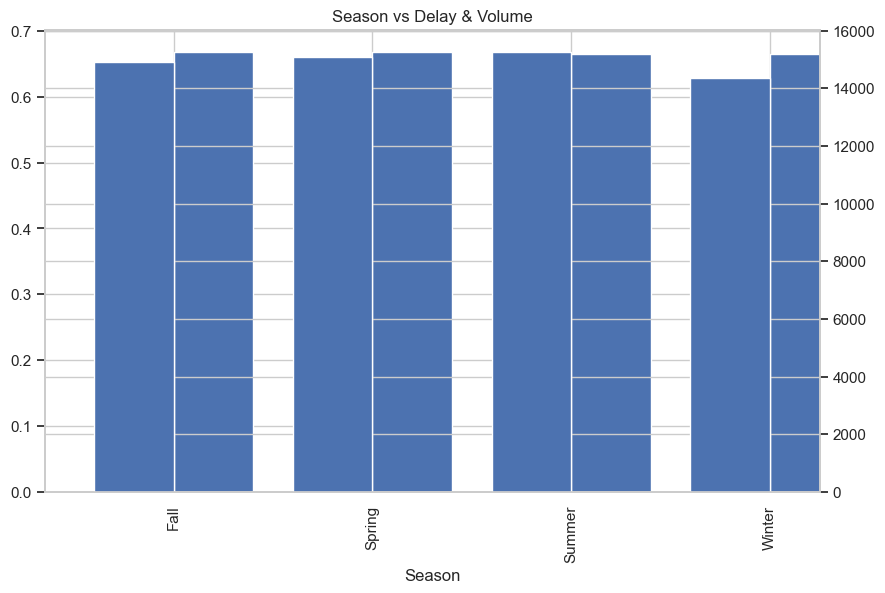

In [11]:
season_stats = df.groupby('Season')[delay_flag].mean()
season_volume = df['Season'].value_counts()

compare = pd.concat([season_stats, season_volume], axis=1)
compare.columns = ['Delay_Rate','Volume']

fig, ax1 = plt.subplots()
compare['Delay_Rate'].plot(kind='bar', ax=ax1, width=0.4, position=0)
ax2 = ax1.twinx()
compare['Volume'].plot(kind='bar', ax=ax2, width=0.4, position=1)

plt.title("Season vs Delay & Volume")
plt.xticks(rotation=45)
plt.show()


Seasonal Delay Causes

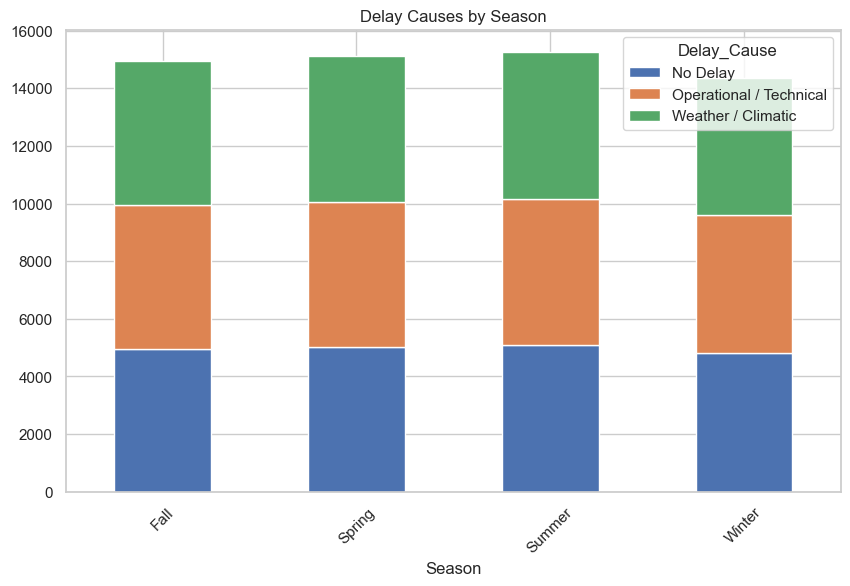

In [12]:
season_cause = pd.crosstab(df['Season'], df[delay_cause])
season_cause.plot(kind='bar', stacked=True)
plt.title("Delay Causes by Season")
plt.xticks(rotation=45)
plt.show()

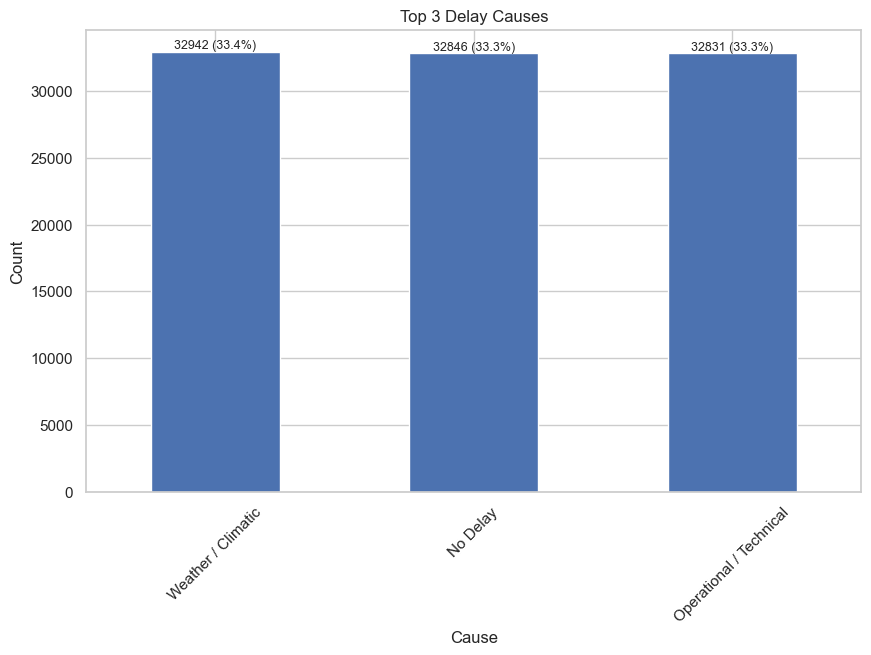

In [13]:
top_causes = df[delay_cause].value_counts().head(3)

plt.figure()
ax = top_causes.plot(kind='bar')
plt.title("Top 3 Delay Causes")
plt.xlabel("Cause")
plt.ylabel("Count")
plt.xticks(rotation=45)
add_labels(ax, total=top_causes.sum())
plt.show()

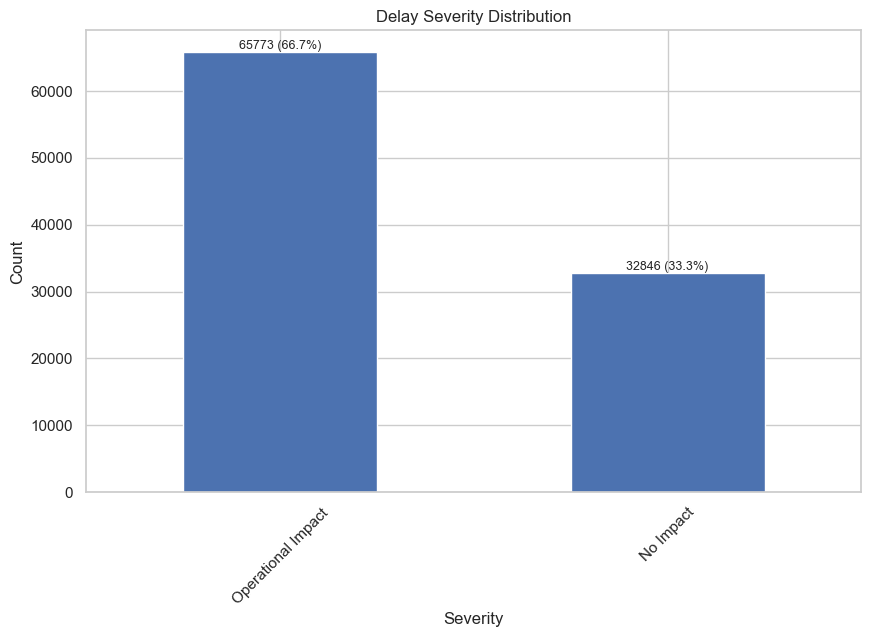

In [14]:
severity_counts = df['Delay_Severity'].value_counts()

plt.figure()
ax = severity_counts.plot(kind='bar')
plt.title("Delay Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.xticks(rotation=45)
add_labels(ax, total=severity_counts.sum())
plt.show()



### Week 5–6 Insights

* Seasonal conditions significantly influence delay patterns.
* Certain routes consistently experience higher delays.
* Airport performance varies despite similar traffic levels.
* Delay causes shift across seasons, with weather and congestion being key contributors.
